<a href="https://colab.research.google.com/github/YuniTV/MultiViewDiffusion_HuggingFaceTutorial/blob/main/multi_view_diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi-view Diffusion

Multi-view diffusion is a type of diffusion model that turns an image of an object into multiple views of that object.

## Setup

Install the required libraries.

Here, we use a custom [requirements file](https://huggingface.co/spaces/dylanebert/multi-view-diffusion/blob/main/requirements.txt) to install a large number of dependencies. This is because the [Diffusers](https://huggingface.co/docs/diffusers/en/index) library doesn't officially support multi-view diffusion.

Änderung im Colab:
- Laufzeitversion: 2025.07:

  -- Ubuntu 22.04.04 LTS

  -- Python 3.11.13
  
  -- numpy 2.0.2
  
  -- PyTorch 2.6.0
  
  -- Jax 0.5.2
  
  -- Tensorflow 2.18.0 (not included in TPU runtimes)
  
  -- R version 4.5.1 (2025-06-13) -- "Great Square Root"
  
  -- julia version 1.10.9









In [1]:
!pip install peft==0.10.0

In [2]:
!pip install -r https://huggingface.co/spaces/dylanebert/multi-view-diffusion/raw/main/requirements.txt

## Pipeline

Create a multi-view diffusion pipeline. Diffusers doesn't officially support multi-view-diffusion, so we load a [custom pipeline](https://huggingface.co/docs/diffusers/v0.6.0/en/using-diffusers/custom_pipelines).

In [3]:
import torch
from diffusers import DiffusionPipeline

multi_view_diffusion_pipeline = DiffusionPipeline.from_pretrained(
    "dylanebert/multi-view-diffusion",
    custom_pipeline="dylanebert/multi-view-diffusion",
    torch_dtype=torch.float16,
    trust_remote_code=True,
).to("cuda")

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

Fetching 17 files:   0%|          | 0/17 [00:00<?, ?it/s]

tokenizer/special_tokens_map.json:   0%|          | 0.00/460 [00:00<?, ?B/s]

image_encoder/config.json:   0%|          | 0.00/563 [00:00<?, ?B/s]

...

vae/config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.88G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

Keyword arguments {'trust_remote_code': True} are not expected by MVDreamPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Load the input image.

image/jpeg
JPEG
(512, 512)


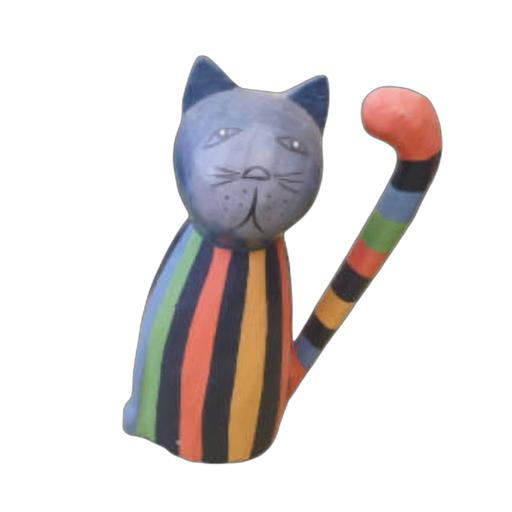

In [4]:
import requests # lädt Bilddaten runter
from PIL import Image # PIL für Bildverarbeitung
from io import BytesIO # io stellt Datei-ähnlichen Datenstrom bereit

# Binärdaten von heruntergeladene Daten werden als Datei-ähnliches Objekt gespeichert und geöffnet
image_url = "https://huggingface.co/datasets/dylanebert/3d-arena/resolve/main/inputs/images/a_cat_statue.jpg"
response = requests.get(image_url) # response enthält die gesamte HTTP-Antwort des Servers, type: # <class 'requests.models.Response'>

# Für Robustness: Status überprüfen
response.raise_for_status()
print(response.headers.get("Content-Type"))

# image/jpeg
image = Image.open(BytesIO(response.content)) # response.content: Antwortinhalt als rohe Binärdaten
print(image.format)
print(image.size)
image

Pass the image through the multi-view diffusion pipeline.

In [5]:
import numpy as np

# Helper Function to display the results in a grid:
# Expected inputs: list or array of images with normalized pixel values between 0 and 1
def create_image_grid(images):
    images = [Image.fromarray((img * 255).astype("uint8")) for img in images] # Image.fromarray() creates PIL-Object from array

    width, height = images[0].size
    grid_img = Image.new("RGB", (2 * width, 2 * height))

    grid_img.paste(images[0], (0, 0))
    grid_img.paste(images[1], (width, 0))
    grid_img.paste(images[2], (0, height))
    grid_img.paste(images[3], (width, height))

    return grid_img


(512, 512, 3)


  0%|          | 0/30 [00:00<?, ?it/s]

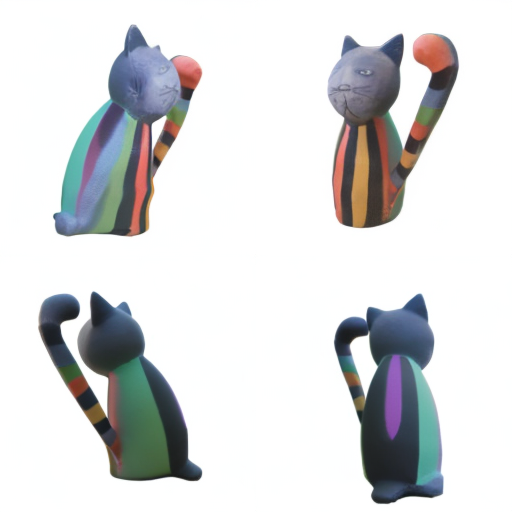

In [6]:
image = np.array(image, dtype=np.float32) / 255.0
print(image.shape)
images = multi_view_diffusion_pipeline("", image, guidance_scale=5, num_inference_steps=30, elevation=0)

create_image_grid(images)

## Gradio Demo

In [ ]:
import gradio as gr

def run(image):
  image = np.array(image, dtype=np.float32) / 255.0
  images = multi_view_diffusion_pipeline("", image, guidance_scale=5, num_inference_steps=30, elevation=0)

  images = [Image.fromarray((img * 255).astype("uint8")) for img in images]

  width, height = images[0].size
  grid_img = Image.new("RGB", (2 * width, 2 * height))

  grid_img.paste(images[0], (0, 0))
  grid_img.paste(images[1], (width, 0))
  grid_img.paste(images[2], (0, height))
  grid_img.paste(images[3], (width, height))

  return grid_img

demo = gr.Interface(fn=run, inputs="image", outputs="image")
demo.launch()

Setting queue=True in a Colab notebook requires sharing enabled. Setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
IMPORTANT: You are using gradio version 4.24.0, however version 4.29.0 is available, please upgrade.
--------
Running on public URL: https://565bb446d7df3075dc.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)
